Purpose: Investigate results of CAM gene TPM regression between parents & each Yg genotype.<br>
Author: Anna Pardo<br>
Date initiated: Mar. 9, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load results df
res = pd.read_csv("./Yg_parents_CAMgene_regression_results.txt",sep="\t",header="infer")
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique
0,YufilH1072272m.g,51,D,1.000000,1.000000,possible_fac_CAM,Yf,PPCK,Yf_PPCK_5
1,YufilH1034994m.g,15,D,0.999981,0.999963,facultative_CAM,Yf,NAD-MDH-cp,Yf_NAD-MDH-cp_3
2,YufilH1044442m.g,15,D,0.999935,0.999869,facultative_CAM,Yf,BPPC,Yf_BPPC
3,YufilH1032169m.g,52,D,0.995784,0.994378,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2
4,YufilH1032169m.g,1AB,D,0.994326,0.992907,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2


In [46]:
min(res["adjr2"])

-0.9994128407063736

In [7]:
# gene families of most interest (strongest time structuring): BPPC, PPPC, PPCK, PPDK, NAD-MDH-cp, NADP-ME
## for each genotype & gene: is the (adjusted) R2 higher for Ya or Yf-derived gene copies?
sg = []
for i in list(res["GeneID"]):
    if i.startswith("Yufil"):
        sg.append("Yf")
    else:
        sg.append("Ya")
res["subgenome"] = sg
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique,subgenome
0,YufilH1072272m.g,51,D,1.000000,1.000000,possible_fac_CAM,Yf,PPCK,Yf_PPCK_5,Yf
1,YufilH1034994m.g,15,D,0.999981,0.999963,facultative_CAM,Yf,NAD-MDH-cp,Yf_NAD-MDH-cp_3,Yf
2,YufilH1044442m.g,15,D,0.999935,0.999869,facultative_CAM,Yf,BPPC,Yf_BPPC,Yf
3,YufilH1032169m.g,52,D,0.995784,0.994378,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2,Yf
4,YufilH1032169m.g,1AB,D,0.994326,0.992907,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2,Yf


In [8]:
len(res["gene_abbr"].unique())

12

In [18]:
res.sort_values(by=["gene_abbr","subgenome"],inplace=True)

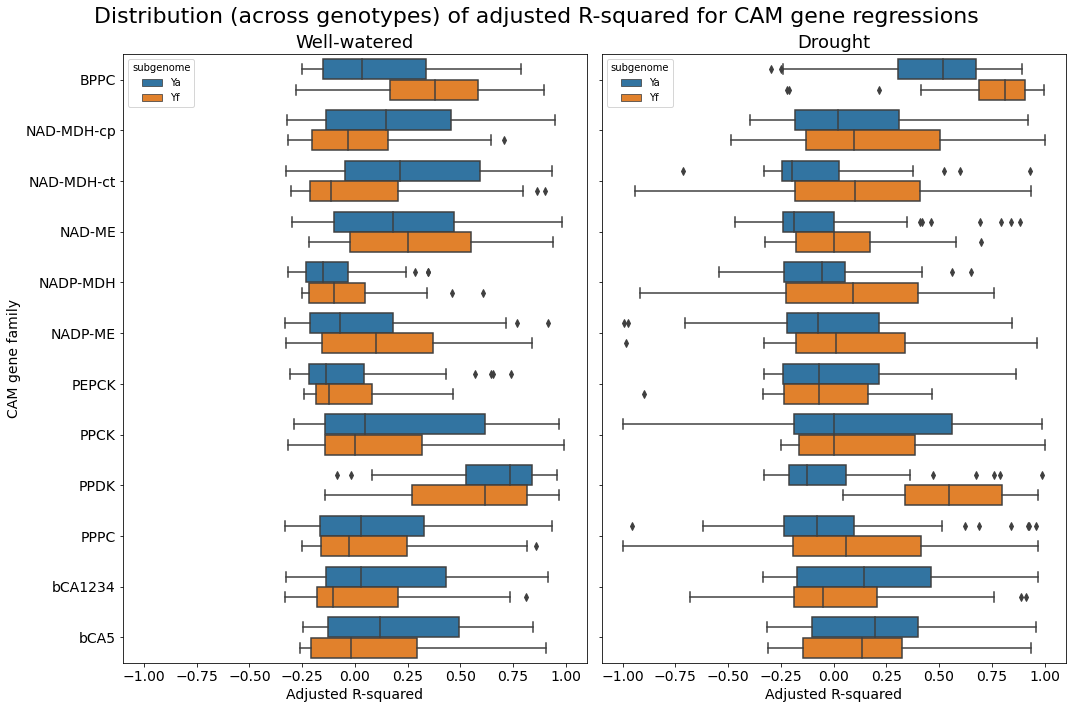

In [32]:
# make a boxplot: x=gene family, y=adjr2, hue=subgenome
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,10),sharey=True,sharex=True)
sns.boxplot(ax=ax[0],data=res[res["treatment"]=="W"],y="gene_abbr",x="adjr2",hue="subgenome")
ax[0].set_title("Well-watered",fontsize=18)
ax[0].set_xlabel("Adjusted R-squared",fontsize=14)
ax[0].tick_params(which="both",labelsize=14)
ax[0].set_ylabel("CAM gene family",fontsize=14)

sns.boxplot(ax=ax[1],data=res[res["treatment"]=="D"],y="gene_abbr",x="adjr2",hue="subgenome")
ax[1].set_title("Drought",fontsize=18)
ax[1].set_ylabel("")
ax[1].set_xlabel("Adjusted R-squared",fontsize=14)
ax[1].tick_params(which="both",labelsize=14)

plt.suptitle("Distribution (across genotypes) of adjusted R-squared for CAM gene regressions",fontsize=22)

fig.tight_layout()

plt.savefig("./adjR2_boxplot_bygenefam.png",dpi=200,bbox_inches="tight")
plt.savefig("./adjR2_boxplot_bygenefam.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./adjR2_boxplot_bygenefam.svg",dpi=200,bbox_inches="tight")

In [29]:
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique,subgenome
2980,Yucal.07G108400.v2.1,51,W,0.024466,-0.219417,possible_fac_CAM,Ya,BPPC,Ya_BPPC_2,Ya
1506,Yucal.07G108500.v2.1,Eudy,W,0.309986,0.137482,C3,Ya,BPPC,Ya_BPPC_3,Ya
2966,Yucal.07G108500.v2.1,48,W,0.025933,-0.217584,facultative_CAM,Ya,BPPC,Ya_BPPC_3,Ya
1562,Yucal.07G108500.v2.1,50,D,0.295117,0.060156,NaN,Ya,BPPC,Ya_BPPC_3,Ya
1560,Yucal.07G108400.v2.1,50,W,0.295313,0.119141,NaN,Ya,BPPC,Ya_BPPC_2,Ya


In [30]:
res["sgtreat"] = res["subgenome"]+"_"+res["treatment"]

In [43]:
# some promising results here for PPDK & BPPC, even with all genotypes lumped together
## repeat this for each genotype
def plot_r2_genotype(gt):
    df = res[res["genotype"]==gt]
    p = df["CAMphys"].unique()[0]
    if type(p)!=str:
        p = "no data"
    
    fig,ax = plt.subplots(figsize=(7,12))
    sns.boxplot(data=df,y="gene_abbr",x="adjr2",hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],palette="tab20")
    ax.set_xlabel("Adjusted R-squared",fontsize=14)
    ax.tick_params(which="both",labelsize=14)
    ax.set_ylabel("CAM gene family",fontsize=14)

    plt.title("Adjusted R-squared for CAM gene regressions in genotype "+gt+" ("+p+")",fontsize=18)

    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".png",dpi=200,bbox_inches="tight")
    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".svg",dpi=200,bbox_inches="tight")

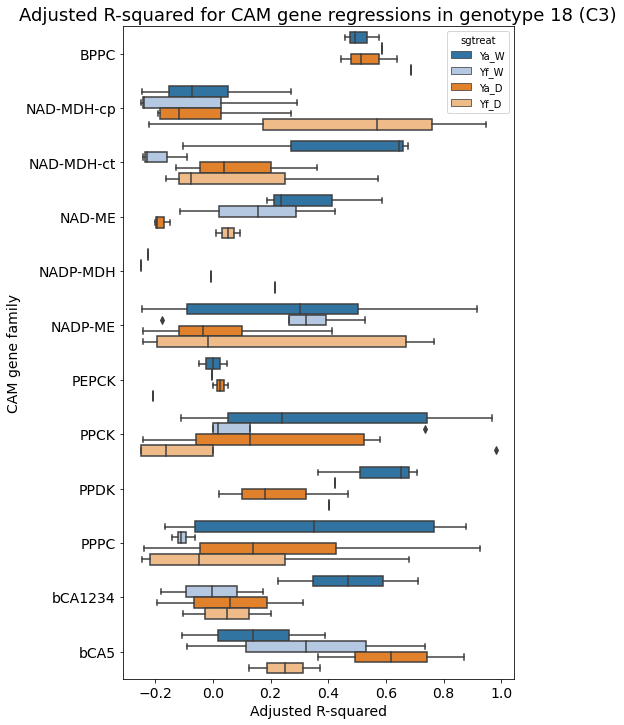

In [44]:
plot_r2_genotype("18")

In [45]:
# do this for all genotypes
for g in res["genotype"].unique():
    plot_r2_genotype(g)
    plt.cla()
    plt.clf()

/tmp/ipykernel_111/1986953205.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(figsize=(7,12))


<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

...

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>